In [1]:
import sys
sys.path.append("../../")
from src.rag.schemas import (
    MainState,
    ReactOutputStructured,
    decomposer_structured_response
)
from src.rag.nodes import (
    retriever_rag,
    aggregator,
    router_decomposer
)
#ports
from src.rag.ports import (
    rag_search,
    llm_port,
    EmbeddingPort
)
#adapters
from src.services import (
    OpenSearchClient,
    create_llm, 
    VectorProcessor
)

from langgraph.graph import START, END, StateGraph
from langgraph.constants import Send
from langchain_core.messages import HumanMessage
from IPython.display import Image, display

In [2]:
gpt_4o_mini = create_llm() #default = gpt-4o-mini | rag_retriever
gpt_4o = create_llm(provider="openai", model="gpt-4o")
chat_decomposer = gpt_4o.with_structured_output(decomposer_structured_response)
chat_aggregator = gpt_4o.with_structured_output(ReactOutputStructured)

opensearch_client = OpenSearchClient()
rag_port = rag_search(opensearch_client)
embedding_converter = EmbeddingPort(VectorProcessor())

2026-04-02 10:27:49 - src.services.llm_factory - INFO - Criando cliente OpenAI com modelo: gpt-4o-mini
2026-04-02 10:27:51 - src.services.llm_factory - INFO - Criando cliente OpenAI com modelo: gpt-4o
2026-04-02 10:27:51 - src.services.opensearch - INFO - Connection with OpenSearch has been achieved. Version: 3.5.0
2026-04-02 10:27:53 - src.services.embedding_processor - INFO - Embed Model successfully loaded. Its dimensions is: 3072


In [3]:
def RouterNode(state:MainState):
    async_rag_agent = router_decomposer(
        state=state,
        embedding_converter_port=embedding_converter.convert_query,
        chat_output_structured_port=chat_decomposer,
        how_many_questions_decomposed=3
    )
    return async_rag_agent

In [4]:
def retriver_node_builder(state: MainState):
    results_from_rag = retriever_rag(
        state=state,
        rag_port=rag_port,
        chat_port=gpt_4o_mini,
        k=7,
        min_score=0.4
        )
    return results_from_rag

In [5]:
def AggregatorNode(state:MainState):
    user_final_response = aggregator(
        state=state,
        aggregator_chat_port=chat_aggregator,
        academic_mode=True
    )
    return user_final_response

In [6]:
def async_rag(state:MainState):
    rag_jobs = state["decomposed_queries"]
    async_package = [Send("Agent_Rag", {"retrieval_rag_input":rag_input}) for rag_input in rag_jobs]
    return async_package

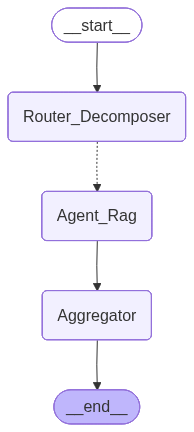

In [7]:
builder = StateGraph(MainState)
builder.add_node("Router_Decomposer", RouterNode)
builder.add_node("Agent_Rag", retriver_node_builder)
builder.add_node("Aggregator", AggregatorNode)

builder.add_edge(START, "Router_Decomposer")
builder.add_conditional_edges(
    "Router_Decomposer",
    async_rag,
    ["Agent_Rag"]
)
builder.add_edge("Agent_Rag", "Aggregator")
builder.add_edge("Agent_Rag", END)

graph_execute = builder.compile()
display(Image(graph_execute.get_graph(xray=True).draw_mermaid_png()))

In [26]:
prompt = "Does the paper mention metrics related to accuracy loss due to atoms of confusion? I mean, values to understand the side affect."
pdf_title = "atoms_confusion.pdf"
abstract = """
ABSTRACT Code comprehension is crucial in software maintenance activities, 
though it can be hindered by misunderstandings and confusion 
patterns, namely, atoms of confusion. They are small pieces of code 
using specific programming language constructs, such as Condi- 
tional Operators and Comma Operators. A previous study showed 
that code comparison was an independent variable to assess coding 
time and accuracy, and increase code misunderstandings. However, 
empirical knowledge of the impact of such atoms on code compre- 
hension is still scarce, especially when it comes to analyzing that 
impact on developers' visual attention. The present study evalu- 
ates whether developers misunderstand the code in the presence 
of atoms of confusion with an eye tracker. For this purpose, we 
examined the effect of code on the screen and analyzed them, and 
analyze the distribution of visual attention. We conducted a 
controlled experiment with 30 students and software practitioners. 
We ask the subjects to specify the output of three tasks with atoms 
and three without atoms randomly assigned using a L400 Square 
design. We use an eye-tracking camera to detect the visual atten- 
tion of each atom and note the times of each atom's attention. In this 
perspective, we observed an increase of 43.02% in the time taken 
to gaze transcode in code snippets with atoms. For accuracy, no 
statistically significant difference was observed. We also confirm 
that the regions that receive most of the eye attention were the regions with atoms. Our findings reinforce that actors hinder de-
velopment of technical comprehension. So, developers should
avoid writing code with ill-structured sentences.
"""

input_config = {
    "messages": [HumanMessage(prompt)],
    "possibles_pdfs_titles": [
        {
            "title": pdf_title,
            "abstract": abstract
        }
    ]
}

In [27]:
output = graph_execute.invoke(input_config)

2026-04-02 10:43:13 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-04-02 10:43:13 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-04-02 10:43:13 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'


In [19]:
output["decomposed_queries"][0]

{'index_name': 'content-pdfs',
 'query_vector': [-0.013791787438094616,
  0.00897279940545559,
  -0.01900704950094223,
  -0.010494212619960308,
  -0.02229047194123268,
  -0.02093181386590004,
  0.009765349328517914,
  0.023734046146273613,
  -0.007755668833851814,
  -0.0034019507002085447,
  0.0049888198263943195,
  -0.03147556260228157,
  -0.009843189269304276,
  0.0026182460132986307,
  0.01794559881091118,
  0.0323813334107399,
  0.017138896510004997,
  0.014230520464479923,
  -0.0022025108337402344,
  -0.002630629576742649,
  0.03858020901679993,
  -0.04831725358963013,
  -0.03741968795657158,
  0.026451360434293747,
  -0.011711343191564083,
  0.005123270209878683,
  -0.013975772075355053,
  -0.01636049896478653,
  -0.01623312383890152,
  0.02686178870499134,
  -0.014704635366797447,
  0.0073806229047477245,
  -0.0025244844146072865,
  -0.05859209969639778,
  -0.009326616302132607,
  -0.021497922018170357,
  0.03424948826432228,
  -0.04758131131529808,
  0.004744686186313629,
  -0.

In [28]:
# What evidence is presented regarding the impact of atoms of confusion on code comprehension, particularly in terms of time, accuracy, and visual attention, as observed in studies utilizing eye-tracking technology?
for sub_queries in output["decomposed_queries"]:
    print(sub_queries["query_text"])

What metrics are mentioned in the paper regarding accuracy loss due to atoms of confusion?
Does the paper provide specific values or statistics to quantify the accuracy loss caused by atoms of confusion?
How does the paper measure the side effects of atoms of confusion on code comprehension accuracy?


In [29]:
for reports in output["retrieval_reports"]:
    print(f"""<<Question>>: {reports["sub_question"]} \n<<Answer>>: {reports["rag_report"]}\n\n\n""")

<<Question>>: What metrics are mentioned in the paper regarding accuracy loss due to atoms of confusion? 
<<Answer>>: The paper mentions several metrics regarding accuracy loss due to atoms of confusion. Here are the key metrics extracted from the context:

1. **Time**: The percentage increase in time spent due to the presence of atoms. For example, the Logic as Control Flow (LACF) atom showed a significant increase in time spent, specifically 91.7%.

2. **Errors**: This metric indicates the percentage of errors made by participants. The LACF atom had the lowest error rate at 8.10%.

3. **Points in AO (Areas of Interest)**: This refers to the percentage of gaze points within designated Areas of Interest. The LACF atom had the highest percentage of gaze points at 28.2%.

4. **Errors in AO**: This metric shows the percentage of errors occurring within the Areas of Interest. The LACF atom had a percentage of 47.8% for errors in AO.

5. **Gaze Transitions (Gaze Trans.)**: This represents t

In [30]:
print(output["messages"][-1].content)

The paper provides several metrics to quantify the side effects of atoms of confusion on code comprehension, although it notes that no statistically significant difference in accuracy was observed. Here are the key metrics and their values:

1. **Time**: There is a 91.7% increase in time spent due to the presence of atoms, specifically for the Logic as Control Flow (LACF) atom.

2. **Errors**: The error rate for the LACF atom is 8.10%.

3. **Points in AO (Areas of Interest)**: The LACF atom has the highest percentage of gaze points within the AO at 28.2%.

4. **Errors in AO**: The percentage of errors occurring within the AO for the LACF atom is 47.8%.

5. **Gaze Transitions**: The LACF atom shows the highest percentage of gaze transitions at 22.7%.

These metrics indicate that atoms of confusion significantly impact developers' focus and time spent on code comprehension tasks. However, the study found no statistically significant difference in accuracy, meaning that while developers m